In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

data = json.load(open('../../data/E-MTAB-3321/outputs/results.json')) 

rows = []
for run in data['runs']:
    # Flatten the metrics into the main dictionary
    row = {
        'algorithm': run['algorithm'],
        'normalization': run['normalization'],
        'with_pca': run['with_pca'],
        **run['metrics']
    }
    rows.append(row)

df = pd.DataFrame(rows)

# Create a combined label for easier plotting of 'Normalization + PCA'
df['setup'] = df['normalization'] + " (PCA: " + df['with_pca'].astype(str) + ")"
df

,algorithm,normalization,with_pca,ari,nmi,jaccard,silhouette,calinski_harabasz,davies_bouldin,setup
0,agglomerative,log_cpm,True,0.543931,0.721000,0.499653,0.157020,18.182415,2.180303,log_cpm (PCA: True)
1,agglomerative,log_cpm,False,0.543931,0.721000,0.499653,0.097305,13.034657,2.600626,log_cpm (PCA: False)
2,agglomerative,pearson,True,0.543223,0.706971,0.498611,0.303831,49.437047,1.315260,pearson (PCA: True)
3,agglomerative,pearson,False,0.543223,0.706971,0.498611,0.199002,29.926322,1.752769,pearson (PCA: False)
4,birch,log_cpm,True,0.543931,0.721000,0.499653,0.157020,18.182415,2.180303,log_cpm (PCA: True)
5,birch,log_cpm,False,0.543931,0.721000,0.499653,0.097305,13.034657,2.600626,log_cpm (PCA: False)
6,birch,pearson,True,0.543223,0.706971,0.498611,0.303831,49.437047,1.315260,pearson (PCA: True)
7,birch,pearson,False,0.543223,0.706971,0.498611,0.199002,29.926322,1.752769,pearson (PCA: False)
8,hdbscan,log_cpm,True,0.415877,0.497886,0.437518,0.080000,10.522833,2.680984,log_cpm (PCA: True)
9,hdbscan,log_cpm,False,0.435518,0.586160,0.450591,0.039321,10.371552,2.879521,log_cpm (PCA: False)


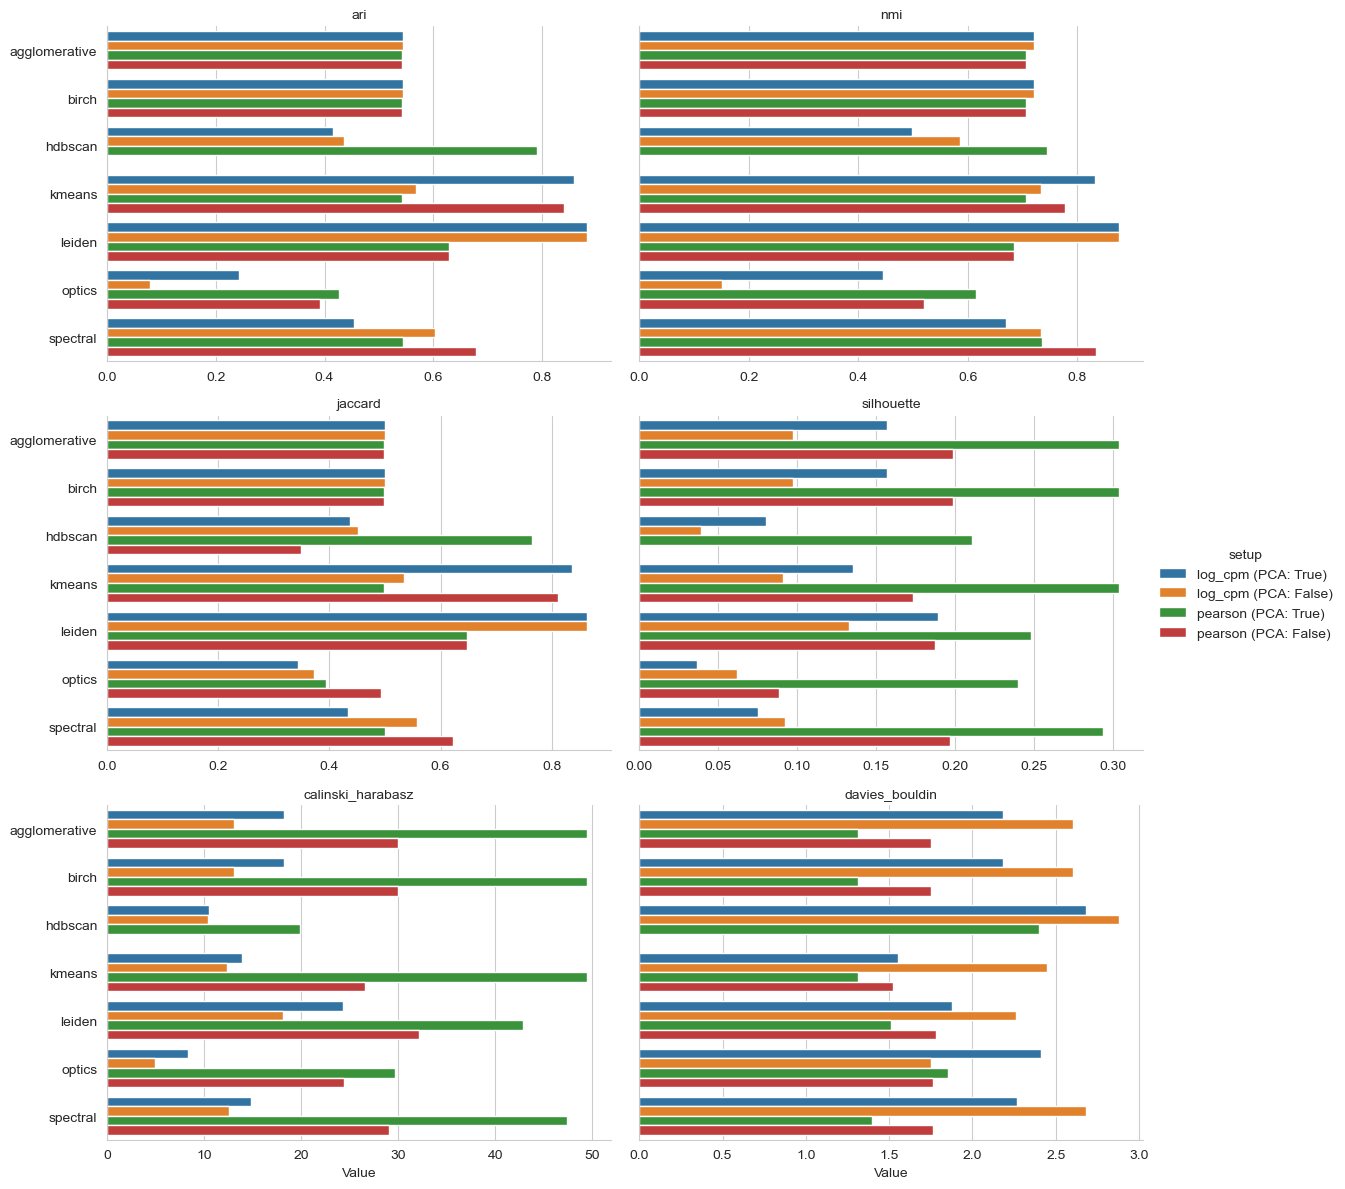

In [15]:
# This also defines the order of the subplots
target_metrics = [
    'ari', 'nmi', 'jaccard',
    'silhouette',
    'calinski_harabasz',
    'davies_bouldin'
]

df_melted_all = df.melt(
    id_vars=['algorithm', 'setup'], 
    value_vars=target_metrics,
    var_name='Metric', 
    value_name='Score'
)

g = sns.catplot(
    data=df_melted_all,
    y='algorithm',
    x='Score',
    hue='setup',
    col='Metric', 
    col_wrap=2,
    kind='bar',
    height=4,
    aspect=1.5,
    sharex=False
)

g.set_axis_labels("Value", "")
g.set_titles("{col_name}")
plt.show()

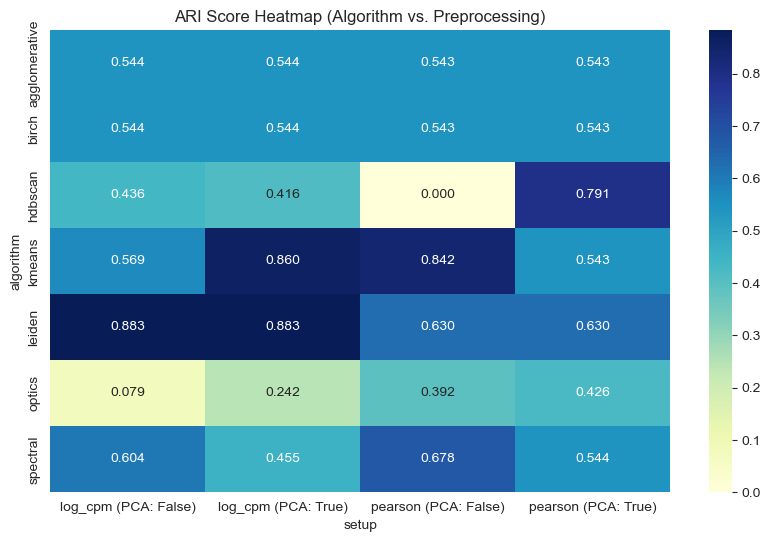

In [5]:
pivot_df = df.pivot_table(index='algorithm', columns='setup', values='ari')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("ARI Score Heatmap (Algorithm vs. Preprocessing)")
plt.show()